# Delhi House Sale Prediction

#### Imporing Libraries




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score ,mean_absolute_error, mean_squared_error, root_mean_squared_error

### Importing dataset

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving delhihousesales.xlsx to delhihousesales (2).xlsx


In [ ]:
delhihousesales = pd.read_excel("delhihousesales.xlsx")

#### Exploratory Data Analysis - (EDA)

In [ ]:
# head- To view top five rows

delhihousesales.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,1774.276388,2.0,2023,Delhi,Main Road,Semi-Furnished,Apartment,No,516094.0
1,NaN,5.0,2000,Delhi,Corner Plot,Semi-Furnished,Apartment,No,585692.0
2,2777.141066,2.0,2020,Delhi,Gated Society,Furnished,Apartment,No,767737.0
3,1134.993085,2.0,2012,Delhi,Gated Society,Furnished,Independent House,No,471846.0
4,2129.817363,7.0,2015,Delhi,Corner Plot,Furnished,Apartment,No,686516.0


In [ ]:
# tail - To view last fiev rows from the dataset

delhihousesales.tail()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
139,2482.465330,4.0,2009,Delhi,Gated Society,Semi-Furnished,Apartment,No,665865.0
140,1686.215186,5.0,2016,Delhi,Highway Facing,Furnished,Apartment,No,587575.0
141,2657.480800,7.0,2001,Delhi,Corner Plot,Furnished,Apartment,No,763812.0
142,1895.830351,5.0,1993,Delhi,Highway Facing,Semi-Furnished,Apartment,No,555886.0
143,NaN,6.0,2022,Delhi,Main Road,Unfurnished,Independent House,No,533436.0


In [ ]:
# info() - To get data information

delhihousesales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      139 non-null    float64
 1   Rooms          140 non-null    float64
 2   Build_Year     144 non-null    int64  
 3   Location       144 non-null    object 
 4   Street_Type    144 non-null    object 
 5   Furnishing     138 non-null    object 
 6   Property_Type  144 non-null    object 
 7   Has_Pool       144 non-null    object 
 8   Price          144 non-null    float64
dtypes: float64(3), int64(1), object(5)
memory usage: 10.3+ KB


In [ ]:
# dtype- To get dtypes of the dataset

delhihousesales.dtypes

,0
Area_SqFt,float64
Rooms,float64
Build_Year,int64
Location,object
Street_Type,object
Furnishing,object
Property_Type,object
Has_Pool,object
Price,float64


In [ ]:
# isnull() - To get null values from the dataset


delhihousesales.isnull().sum()

,0
Area_SqFt,5
Rooms,4
Build_Year,0
Location,0
Street_Type,0
Furnishing,6
Property_Type,0
Has_Pool,0
Price,0


In [ ]:
# unique - To getuniqe value from the dataset

delhihousesales["Rooms"].unique()

array([ 2.,  5.,  7.,  3.,  6.,  4., nan])

In [ ]:
# nunique - To get no of unqiue values from teh dataset


delhihousesales['Property_Type'].nunique()

4

In [ ]:
# value_counts - To get frequent values from the dataset

delhihousesales["Build_Year"].value_counts()

,count
Build_Year,
2020,8
1998,8
1994,8
2012,7
1993,7
1992,5
2023,5
2019,5
1999,5


In [ ]:
# describe - To get statistic summary of the dataset

delhihousesales.describe()

,Area_SqFt,Rooms,Build_Year,Price
count,139.000000,140.000000,144.000000,1.440000e+02
mean,2309.892780,4.450000,2004.569444,6.679813e+05
std,790.530483,1.693513,11.405221,1.340706e+05
min,1064.273437,2.000000,1985.000000,2.775040e+05
25%,1884.796161,3.000000,1994.000000,5.836450e+05
50%,2235.119241,4.500000,2002.500000,6.516055e+05
75%,2630.796360,6.000000,2015.000000,7.443732e+05
max,8858.260499,7.000000,2024.000000,1.273975e+06


In [ ]:
delhihousesales.duplicated().sum()

np.int64(0)

In [ ]:
delhihousesales.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,1774.276388,2.0,2023,Delhi,Main Road,Semi-Furnished,Apartment,No,516094.0
1,NaN,5.0,2000,Delhi,Corner Plot,Semi-Furnished,Apartment,No,585692.0
2,2777.141066,2.0,2020,Delhi,Gated Society,Furnished,Apartment,No,767737.0
3,1134.993085,2.0,2012,Delhi,Gated Society,Furnished,Independent House,No,471846.0
4,2129.817363,7.0,2015,Delhi,Corner Plot,Furnished,Apartment,No,686516.0


In [ ]:
# skew - To check distribution of numerical data

delhihousesales['Price'].skew()

np.float64(0.6950358073445456)

In [ ]:

delhihousesales["Area_SqFt"].skew()

np.float64(4.102772453437056)

### Data Cleaning

In [ ]:
# Converting column names to lowercase and trimming extra spaces for easy readability


delhihousesales.columns = delhihousesales.columns.str.strip().str.lower()

In [ ]:
delhihousesales.head()

,area_sqft,rooms,build_year,location,street_type,furnishing,property_type,has_pool,price
0,1774.276388,2.0,2023,Delhi,Main Road,Semi-Furnished,Apartment,No,516094.0
1,NaN,5.0,2000,Delhi,Corner Plot,Semi-Furnished,Apartment,No,585692.0
2,2777.141066,2.0,2020,Delhi,Gated Society,Furnished,Apartment,No,767737.0
3,1134.993085,2.0,2012,Delhi,Gated Society,Furnished,Independent House,No,471846.0
4,2129.817363,7.0,2015,Delhi,Corner Plot,Furnished,Apartment,No,686516.0


In [ ]:
delhihousesales.isnull().sum()

,0
area_sqft,5
rooms,4
build_year,0
location,0
street_type,0
furnishing,6
property_type,0
has_pool,0
price,0


In [ ]:
# Based on skewness of 'area_sqft' (4.2) filling null values with the median

delhihousesales['area_sqft'] = delhihousesales['area_sqft'].fillna(delhihousesales["area_sqft"].median())

In [ ]:
# Based on skewness of 'price' (0.69), filling missing values with the mean

delhihousesales["price"] = delhihousesales["price"].fillna(delhihousesales["price"].mean())

In [ ]:
# Filling categorical column with the mode


delhihousesales["furnishing"] =delhihousesales["furnishing"].fillna(delhihousesales["furnishing"].mode()[0])

In [ ]:
delhihousesales["rooms"] = delhihousesales["rooms"].fillna(delhihousesales["rooms"].mode()[0])

In [ ]:
#cross checking the nulls values

delhihousesales.isnull().sum()

,0
area_sqft,0
rooms,0
build_year,0
location,0
street_type,0
furnishing,0
property_type,0
has_pool,0
price,0


In [ ]:
delhihousesales["street_type"].unique()

array(['Main Road', 'Corner Plot', 'Gated Society', 'Highway Facing',
       'Residential Lane'], dtype=object)

In [ ]:
# Creating dummy variables to convert categorical columns into numeric


delhihousesales = pd.get_dummies(delhihousesales,
                                 columns=["location","street_type","furnishing","property_type","has_pool"])

In [ ]:
delhihousesales

,area_sqft,rooms,build_year,price,location_Delhi,street_type_Corner Plot,street_type_Gated Society,street_type_Highway Facing,street_type_Main Road,street_type_Residential Lane,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,property_type_Apartment,property_type_Duplex,property_type_Independent House,property_type_Villa,has_pool_No,has_pool_Yes
0,1774.276388,2.0,2023,516094.0,True,False,False,False,True,False,False,True,False,True,False,False,False,True,False
1,2235.119241,5.0,2000,585692.0,True,True,False,False,False,False,False,True,False,True,False,False,False,True,False
2,2777.141066,2.0,2020,767737.0,True,False,True,False,False,False,True,False,False,True,False,False,False,True,False
3,1134.993085,2.0,2012,471846.0,True,False,True,False,False,False,True,False,False,False,False,True,False,True,False
4,2129.817363,7.0,2015,686516.0,True,True,False,False,False,False,True,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2482.465330,4.0,2009,665865.0,True,False,True,False,False,False,False,True,False,True,False,False,False,True,False
140,1686.215186,5.0,2016,587575.0,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False
141,2657.480800,7.0,2001,763812.0,True,True,False,False,False,False,True,False,False,True,False,False,False,True,False
142,1895.830351,5.0,1993,555886.0,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False


In [ ]:
# Based on data analysis, removing street type dummy columns as they are not necessary


delhihousesales = delhihousesales.drop(columns=["street_type_Corner Plot",
        "street_type_Gated Society",
        "street_type_Highway Facing",
        "street_type_Main Road",
        "street_type_Residential Lane"])

In [ ]:
delhihousesales.head()

,area_sqft,rooms,build_year,price,location_Delhi,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,property_type_Apartment,property_type_Duplex,property_type_Independent House,property_type_Villa,has_pool_No,has_pool_Yes
0,1774.276388,2.0,2023,516094.0,True,False,True,False,True,False,False,False,True,False
1,2235.119241,5.0,2000,585692.0,True,False,True,False,True,False,False,False,True,False
2,2777.141066,2.0,2020,767737.0,True,True,False,False,True,False,False,False,True,False
3,1134.993085,2.0,2012,471846.0,True,True,False,False,False,False,True,False,True,False
4,2129.817363,7.0,2015,686516.0,True,True,False,False,True,False,False,False,True,False


### Creating X and Y Variables, Train-Test Split, and Model

In [ ]:
delhihousesales.head()

,area_sqft,rooms,build_year,price,location_Delhi,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,property_type_Apartment,property_type_Duplex,property_type_Independent House,property_type_Villa,has_pool_No,has_pool_Yes
0,1774.276388,2.0,2023,516094.0,True,False,True,False,True,False,False,False,True,False
1,2235.119241,5.0,2000,585692.0,True,False,True,False,True,False,False,False,True,False
2,2777.141066,2.0,2020,767737.0,True,True,False,False,True,False,False,False,True,False
3,1134.993085,2.0,2012,471846.0,True,True,False,False,False,False,True,False,True,False
4,2129.817363,7.0,2015,686516.0,True,True,False,False,True,False,False,False,True,False


In [ ]:
x = delhihousesales.drop(columns=["price"])

In [ ]:
y = delhihousesales["price"]

In [ ]:
# Training, testing and splitting the data


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=42)

In [ ]:
#Creating model

delhihousesales_model = LinearRegression()

In [ ]:
delhihousesales_model

LinearRegression()

In [ ]:
# Fitting the independent and dependent variables


delhihousesales_model.fit(x_train,y_train)

LinearRegression()

In [ ]:
# Predicting the dependent variable using indipendent test dat


delhihousesales_predict = delhihousesales_model.predict(x_test)

In [ ]:
delhihousesales_predict

array([670070.98926908, 466946.76325724, 581041.92934021, 546111.75332945,
       712819.02685128, 709018.91390053, 645499.56028002, 761685.66945796,
       543681.50964431, 612906.02207447, 530917.48601397, 646140.15037565,
       721814.37814256, 565242.07686009, 720336.38448343, 766140.79414427,
       965009.87263834, 692979.28961473, 615546.18538139, 627930.45345658,
       646861.19930731, 713999.05224313, 589697.90948299, 657438.00944792,
       661231.00808019, 535461.15300854, 902856.78583537, 687281.73949137,
       854079.13115272])

### Evaluating the Model Metrics

In [ ]:
# R² Score - To check how well the model explains the differences in house prices


r2score = r2_score(y_test,delhihousesales_predict)

print("r2_score is =",r2score)

r2_score is = 0.8390478242125712


In [ ]:
# Mean_absolute_error - To view average prediction erros

mae = mean_absolute_error(y_test,delhihousesales_predict)

print("Average_Prediction_Error is =",mae)

Average_Prediction_Error is = 34609.91263805995


In [ ]:
# Mean_Squared_Error -To measure prediction errors with more weight on larger errors


mse = mean_squared_error(y_test,delhihousesales_predict)

print("Mean_Squared_Error is =",mse)

Mean_Squared_Error is = 3491338925.300427


In [ ]:
# root_mean_squared_error - To view actual prediction error


rmse = root_mean_squared_error(y_test,delhihousesales_predict)

print("Root Mean Squared Error =",rmse)

Root Mean Squared Error = 59087.553048848


| Metric       |          Your Result | Simple Meaning                                                    |
| ------------ | -------------------: | ----------------------------------------------------------------- |
| **R² Score** |   **0.8390 (83.9%)** | Model explains about **83.9% of the differences in house prices** |
| **MAE**      |       **₹34,609.91** | Average prediction error is about **₹34,610**                     |
| **MSE**      | **3,491,338,925.30** | Measures squared errors and gives more weight to large errors     |
| **RMSE**     |       **₹59,087.55** | Typical prediction error is around **₹59,088**                    |


### Vizualization

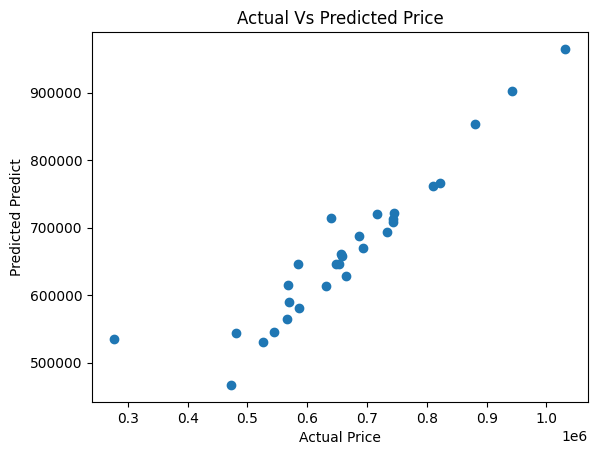

In [ ]:
plt.scatter(x=y_test,y=delhihousesales_predict)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Predict")
plt.title("Actual Vs Predicted Price")
plt.show()

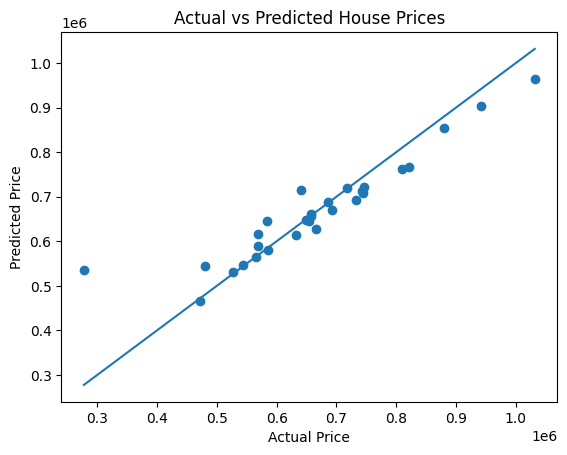

In [ ]:
plt.scatter(x=y_test, y=delhihousesales_predict)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [ ]:
delhihousesales.head()

,area_sqft,rooms,build_year,price,location_Delhi,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,property_type_Apartment,property_type_Duplex,property_type_Independent House,property_type_Villa,has_pool_No,has_pool_Yes
0,1774.276388,2.0,2023,516094.0,True,False,True,False,True,False,False,False,True,False
1,2235.119241,5.0,2000,585692.0,True,False,True,False,True,False,False,False,True,False
2,2777.141066,2.0,2020,767737.0,True,True,False,False,True,False,False,False,True,False
3,1134.993085,2.0,2012,471846.0,True,True,False,False,False,False,True,False,True,False
4,2129.817363,7.0,2015,686516.0,True,True,False,False,True,False,False,False,True,False


### New_House Prediction

In [ ]:
# Creating new Delhi apartment data for price prediction

new_delhi_apartment_sale = pd.DataFrame({

    "area_sqft": [1800, 2000, 2200],
    "rooms": [3, 4, 4],
    "build_year": [2024, 2024, 2024],
    "location_Delhi": [True, True, True],
    "furnishing_Furnished": [True, False, True],
    "furnishing_Semi-Furnished": [False, True, False],
    "furnishing_Unfurnished": [False, False, False],
    "property_type_Apartment": [True, True, True],
    "property_type_Duplex": [False, False, False],
    "property_type_Independent House": [False, False, False],
    "property_type_Villa": [False, False, False],
    "has_pool_No": [True, True, True],
    "has_pool_Yes": [False, False, False]
})

In [ ]:
# Predicting prices for new Delhi apartment houses

new_delhi_apartment_prediction = delhihousesales_model.predict(
    new_delhi_apartment_sale
)

print(new_delhi_apartment_prediction)

[587533.64217825 605960.79366944 659783.82540638]


In [ ]:
new_delhi_duplex_sale = pd.DataFrame({

    "area_sqft": [1800, 2000, 2200],
    "rooms": [4, 4, 4],
    "build_year": [2024, 2024, 2024],
    "location_Delhi": [True, True, True],
    "furnishing_Furnished": [False, False, True],
    "furnishing_Semi-Furnished": [False, True, False],
    "furnishing_Unfurnished": [True, False, False],
    "property_type_Apartment": [False, False, False],
    "property_type_Duplex": [True, True, True],
    "property_type_Independent House": [False, False, False],
    "property_type_Villa": [False, False, False],
    "has_pool_No": [True, True, True],
    "has_pool_Yes": [False, False, False]
})

In [ ]:
new_delhi_duplex_prediction = delhihousesales_model.predict(
    new_delhi_duplex_sale
)

print(new_delhi_duplex_prediction)

[599752.74463681 680715.55872362 734538.59046056]


In [ ]:
# Creating different new houses for price prediction

new_delhi_houses = pd.DataFrame({

    "area_sqft": [1200, 1800, 2200, 3000],
    "rooms": [2, 3, 4, 5],
    "build_year": [2015, 2020, 2022, 2024],
    "location_Delhi": [True, True, True, True],

    "furnishing_Furnished": [False, True, False, True],
    "furnishing_Semi-Furnished": [True, False, True, False],
    "furnishing_Unfurnished": [False, False, False, False],

    "property_type_Apartment": [True, False, False, False],
    "property_type_Duplex": [False, False, True, False],
    "property_type_Independent House": [False, False, False, True],
    "property_type_Villa": [False, True, False, False],

    "has_pool_No": [True, True, True, False],
    "has_pool_Yes": [False, False, False, True]
})

In [ ]:
# Predicting prices for the newly created houses using the trained Linear Regression model
# Rounding predicted prices to whole numbers for easier readability



new_delhi_houses_prediction =delhihousesales_model.predict(new_delhi_houses)

print(new_delhi_houses_prediction.round())

[449697. 717318. 706049. 866832.]


In [ ]:
# Creating a table to display the new house details and their predicted prices
# Copying selected columns into a new table and adding the predicted prices as a new column

prediction_results = new_delhi_houses[
    ["area_sqft", "rooms", "build_year"]
].copy()

In [ ]:
# Adding the predicted price to the result table

prediction_results["Predicton Price"] =new_delhi_houses_prediction.round()

In [ ]:


print(prediction_results)

   area_sqft  rooms  build_year  Predicton Price
0       1200      2        2015         449697.0
1       1800      3        2020         717318.0
2       2200      4        2022         706049.0
3       3000      5        2024         866832.0
